# Hälsostudie Del 2

I del 2 försöker jag strukturera koden lite bättre än i del 1.
Jag använder några funktioner, en enkel klass och en linjär regression
för att undersöka sambandet mellan blodtryck, ålder och vikt.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

np.random.seed(42)

# Läs in data (samma som i del 1)
df = pd.read_csv("data/health_study_dataset.csv")
df.head()


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


## Funktioner

I del 1 skrev jag det mesta direkt i celler. Här lägger jag
lite av koden i funktioner i stället. Det gör att jag kan
anropa samma logik flera gånger utan att kopiera allt.

Jag börjar med en funktion som läser in data, en som räknar ut
beskrivande statistik och en som ritar ett histogram för blodtrycket.


In [11]:
def load_data(path="data/health_study_dataset.csv"):
    """Läser in csv-filen och returnerar en DataFrame."""
    return pd.read_csv(path)


def basic_stats(df, cols=None):
    """Skriver ut enkel statistik för valda kolumner."""
    if cols is None:
        cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]
    for c in cols:
        mean_v = df[c].mean()
        med_v = df[c].median()
        min_v = df[c].min()
        max_v = df[c].max()
        print(f"{c}: medel={mean_v:.2f}, median={med_v:.2f}, min={min_v:.2f}, max={max_v:.2f}")


def plot_bp_hist(df):
    """Ritar ett enkelt histogram för systoliskt blodtryck."""
    plt.figure()
    plt.hist(df["systolic_bp"].dropna(), bins=15)
    plt.xlabel("Systoliskt blodtryck (mmHg)")
    plt.ylabel("Antal")
    plt.title("Histogram - systoliskt blodtryck")
    plt.show()


Grundläggande statistik (test):
age: medel=49.43, median=50.00, min=18.00, max=90.00
weight: medel=73.41, median=73.20, min=33.70, max=114.40
height: medel=171.85, median=171.35, min=144.40, max=200.40
systolic_bp: medel=149.18, median=149.40, min=106.80, max=185.90
cholesterol: medel=4.93, median=4.97, min=2.50, max=7.88

Histogram-test:


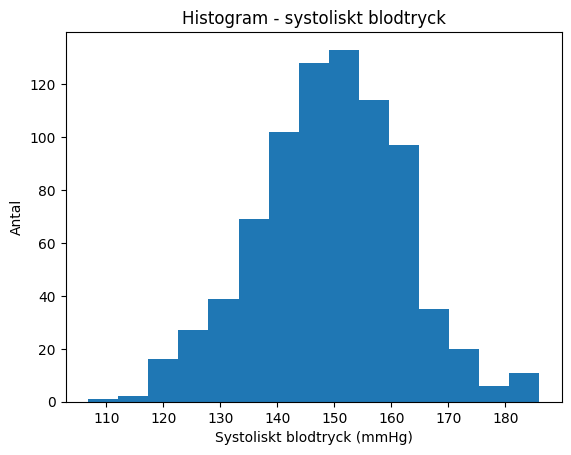

In [12]:
data_test = load_data()

print("Grundläggande statistik (test):")
basic_stats(data_test)

print("\nHistogram-test:")
plot_bp_hist(data_test)


## Klass: HealthAnalyzer

Nu gör jag en liten klass som samlar några analyser.
Den får in hela DataFrame som argument och har metoder för:

- skriva ut statistik
- rita vikt per kön
- räkna sjukdomsförekomst per kön
- göra en linjär regression för blodtryck (ålder + vikt)
- räkna ut R² för modellen


In [13]:
class HealthAnalyzer:
    """En enkel klass för hälsodatat."""

    def __init__(self, df):
        """Sparar undan datan och förbereder variabler."""
        self.df = df
        self._bp_beta = None  # koefficienter för blodtrycksmodellen

    def print_basic_stats(self, cols=None):
        """Använder basic_stats-funktionen på klassens data."""
        basic_stats(self.df, cols)

    def plot_weight_by_sex(self):
        """Boxplot med vikt uppdelad på kön."""
        plt.figure()
        self.df.boxplot(column="weight", by="sex")
        plt.suptitle("")  # tar bort extra titel
        plt.ylabel("Vikt (kg)")
        plt.title("Vikt per kön")
        plt.show()

    def disease_rate_by_sex(self):
        """Returnerar andel med sjukdom per kön."""
        return self.df.groupby("sex")["disease"].mean()

    def fit_bp_regression(self):
        """
        Enkel linjär regression:
        systoliskt blodtryck ~ ålder + vikt.
        """
        X = self.df[["age", "weight"]].values
        y = self.df["systolic_bp"].values

        # lägger till en kolumn med ettor (intercept)
        ones = np.ones((X.shape[0], 1))
        X_design = np.hstack([ones, X])

        # minstakvadrat-lösning
        beta, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
        self._bp_beta = beta
        return beta

    def predict_bp(self, age, weight):
        """Gör en enkel prognos av blodtrycket."""
        if self._bp_beta is None:
            self.fit_bp_regression()
        b0, b_age, b_weight = self._bp_beta
        return b0 + b_age * age + b_weight * weight

    def bp_r2(self):
        """Räknar ut R²-värdet för blodtrycksmodellen."""
        if self._bp_beta is None:
            self.fit_bp_regression()

        X = self.df[["age", "weight"]].values
        y = self.df["systolic_bp"].values
        ones = np.ones((X.shape[0], 1))
        X_design = np.hstack([ones, X])
        y_pred = X_design @ self._bp_beta

        ss_total = np.sum((y - y.mean())**2)
        ss_res = np.sum((y - y_pred)**2)
        r2 = 1 - ss_res / ss_total
        return r2


Grundläggande statistik från klassen:
age: medel=49.43, median=50.00, min=18.00, max=90.00
weight: medel=73.41, median=73.20, min=33.70, max=114.40
height: medel=171.85, median=171.35, min=144.40, max=200.40
systolic_bp: medel=149.18, median=149.40, min=106.80, max=185.90
cholesterol: medel=4.93, median=4.97, min=2.50, max=7.88

Sjukdomsförekomst per kön:
sex
F    0.044665
M    0.073048
Name: disease, dtype: float64

Ritar vikt per kön:


<Figure size 640x480 with 0 Axes>

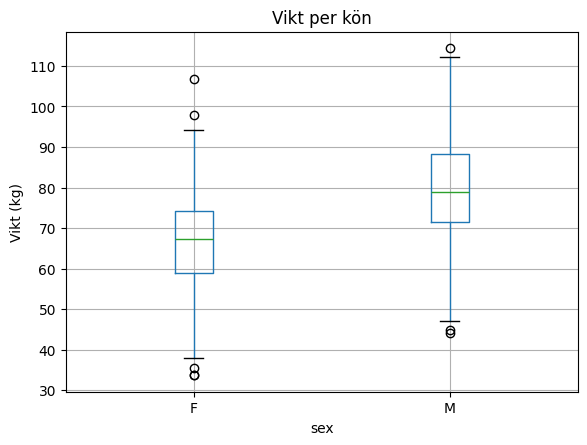


Koefficienter (intercept, ålder, vikt):
[109.49908145   0.53892763   0.17765752]
R² för blodtrycksmodellen: 0.4052560814611623
Exempel: uppskattat blodtryck för 50 år och 80 kg: 150.65806482612726


In [14]:
analyzer = HealthAnalyzer(df)

print("Grundläggande statistik från klassen:")
analyzer.print_basic_stats()

print("\nSjukdomsförekomst per kön:")
print(analyzer.disease_rate_by_sex())

print("\nRitar vikt per kön:")
analyzer.plot_weight_by_sex()

beta = analyzer.fit_bp_regression()
r2 = analyzer.bp_r2()

print("\nKoefficienter (intercept, ålder, vikt):")
print(beta)

print("R² för blodtrycksmodellen:", r2)

example_pred = analyzer.predict_bp(age=50, weight=80)
print("Exempel: uppskattat blodtryck för 50 år och 80 kg:", example_pred)


## Linjär regression och linjär algebra

Här använder jag ålder och vikt för att förklara systoliskt blodtryck
med en enkel linjär regression.

Jag bygger en matris X som består av:
- en kolumn med ettor (intercept)
- en kolumn med ålder
- en kolumn med vikt

Sedan använder jag `numpy.linalg.lstsq` för att lösa minstakvadrat-
problemet och få ut koefficienterna. Det är ett enkelt exempel på hur
matriser används i praktiken.


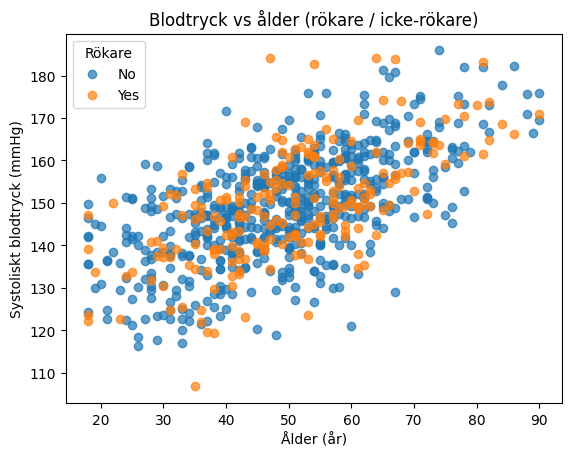

In [15]:
# blodtryck mot ålder, uppdelat på rökare/icke-rökare
plt.figure()
for label, group in df.groupby("smoker"):
    plt.scatter(group["age"], group["systolic_bp"], label=label, alpha=0.7)

plt.xlabel("Ålder (år)")
plt.ylabel("Systoliskt blodtryck (mmHg)")
plt.title("Blodtryck vs ålder (rökare / icke-rökare)")
plt.legend(title="Rökare")
plt.show()


sex
F    0.044665
M    0.073048
Name: disease, dtype: float64


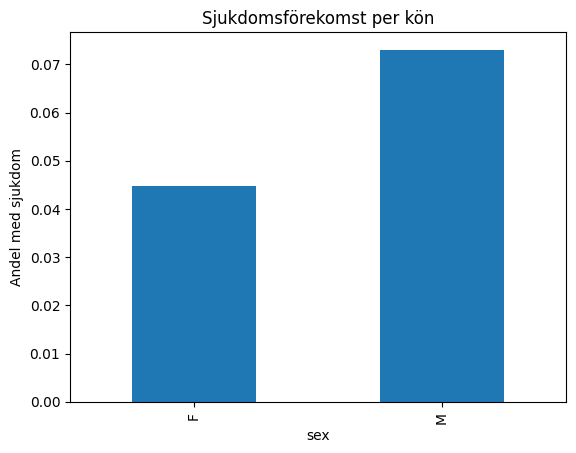

In [16]:
disease_by_sex = analyzer.disease_rate_by_sex()
print(disease_by_sex)

plt.figure()
disease_by_sex.plot(kind="bar")
plt.ylabel("Andel med sjukdom")
plt.title("Sjukdomsförekomst per kön")
plt.show()


## Kort sammanfattning

I del 2 har jag gjort följande:

- lagt några delar i funktioner (t.ex. statistik och histogram)
- skapat en klass (`HealthAnalyzer`) som samlar flera analyser
- gjort en linjär regression där blodtryck förklaras av ålder och vikt
- lagt till extra grafer (blodtryck vs ålder och sjukdom per kön)

Jag använder enkla metoder från `pandas`, `matplotlib` och `numpy`.
För regressionen använder jag `numpy.linalg.lstsq` som är en vanlig
funktion för minstakvadratlösning (finns beskriven i NumPy:s dokumentation).
Jag har försökt hålla allt så rakt och tydligt som möjligt.
